### 軸対称な衛星のトルクフリーモーション

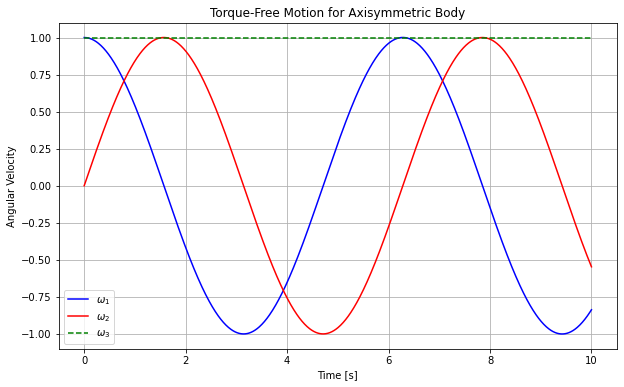

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 剛体慣性モーメント（例として I1=I2=1, I3=2 とする）
I1 = 1.0
I3 = 2.0

# 定数となる ω3 の値（初期値として ω3 = 1）
omega3_const = 1.0

# オイラーの運動方程式（軸対象の場合）
def torque_free(t, omega):
    omega1, omega2, omega3 = omega
    # ω3 は一定なので、dω3/dt = 0
    domega1 = - (I3 - I1)/I1 * omega2 * omega3_const
    domega2 =   (I3 - I1)/I1 * omega1 * omega3_const
    domega3 = 0.0
    return [domega1, domega2, domega3]

# 初期条件: 例として ω1(0)=1, ω2(0)=0, ω3(0)=1
omega0 = [1.0, 0.0, omega3_const]

# シミュレーション時間
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# 数値積分を実行
sol = solve_ivp(torque_free, t_span, omega0, t_eval=t_eval)

# 結果の抽出
t = sol.t
omega1 = sol.y[0]
omega2 = sol.y[1]
omega3 = sol.y[2]

# プロット
plt.figure(figsize=(10, 6))
plt.plot(t, omega1, label=r'$\omega_1$', color='blue')
plt.plot(t, omega2, label=r'$\omega_2$', color='red')
plt.plot(t, omega3, label=r'$\omega_3$', color='green', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Angular Velocity')
plt.title('Torque-Free Motion for Axisymmetric Body')
plt.legend()
plt.grid(True)
plt.show()


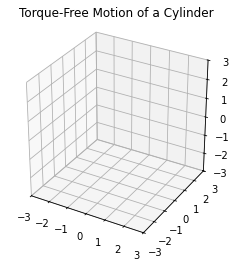

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from mpl_toolkits.mplot3d import Axes3D

# --- クォータニオンの基本操作 ---
def quat_mult(q, r):
    # q, r: [w, x, y, z]
    w1, x1, y1, z1 = q
    w2, x2, y2, z2 = r
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quat_normalize(q):
    return q / np.linalg.norm(q)

def quat_to_rot_matrix(q):
    # q = [w, x, y, z]
    w, x, y, z = q
    R = np.array([
        [1 - 2*(y**2+z**2), 2*(x*y - z*w),   2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x**2+z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),   1 - 2*(x**2+y**2)]
    ])
    return R

# --- シミュレーションパラメータ ---
dt = 0.02       # タイムステップ [s]
total_time = 20  # 総シミュレーション時間 [s]
num_steps = int(total_time/dt)

# 軸対象の剛体（円筒）のトルクフリーモーションの角速度（解析解）
# 初期条件: ω₁(0)=1, ω₂(0)=0, ω₃=1 とするので、解析解では
# ω₁(t)=cos(t), ω₂(t)=sin(t), ω₃(t)=1
def angular_velocity(t):
    return np.array([np.cos(t), np.sin(t), 1.0])

# 初期姿勢は単位クォータニオン（回転なし）
q = np.array([1.0, 0.0, 0.0, 0.0])

# --- 円筒の形状 ---
radius = 1.0   # 円筒の半径
height = 2.0   # 円筒の高さ
num_points = 30

# 上面と下面の円周上の点（局所座標系）
angles = np.linspace(0, 2*np.pi, num_points, endpoint=False)
top_circle = np.array([[radius * np.cos(a), radius * np.sin(a), height/2] for a in angles])
bottom_circle = np.array([[radius * np.cos(a), radius * np.sin(a), -height/2] for a in angles])

# --- matplotlib 3D プロット設定 ---
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_zlim([-3, 3])
ax.set_box_aspect([1,1,1])
ax.set_title("Torque-Free Motion of a Cylinder")

# グローバルなシミュレーション時刻
time_elapsed = 0.0

def init():
    ax.cla()
    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_zlim([-3, 3])
    ax.set_box_aspect([1,1,1])
    ax.set_title("Torque-Free Motion of a Cylinder")
    return []

def update(frame):
    global q, time_elapsed
    time_elapsed += dt
    
    # 現在時刻の角速度（解析解）
    omega = angular_velocity(time_elapsed)
    # 角速度を純虚数クォータニオンに変換: (0, ω₁, ω₂, ω₃)
    omega_quat = np.concatenate(([0.0], omega))
    
    # クォータニオン微分: dq/dt = 0.5 * q ⊗ omega_quat
    dq = 0.5 * quat_mult(q, omega_quat)
    q = q + dq * dt
    q = quat_normalize(q)
    
    # 現在の姿勢から回転行列を取得
    R = quat_to_rot_matrix(q)
    
    # 局所座標系の円筒の各点に回転を適用
    top_rot = (R @ top_circle.T).T   # (num_points, 3)
    bottom_rot = (R @ bottom_circle.T).T
    
    # プロットをクリアして再描画
    ax.cla()
    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_zlim([-3, 3])
    ax.set_box_aspect([1,1,1])
    ax.set_title("Torque-Free Motion of a Cylinder")
    
    # 上面・下面の円周を描画
    ax.plot(top_rot[:,0], top_rot[:,1], top_rot[:,2], color='b')
    ax.plot(bottom_rot[:,0], bottom_rot[:,1], bottom_rot[:,2], color='b')
    # 上面と下面を結ぶ縦線を描画
    for i in range(num_points):
        xs = [top_rot[i,0], bottom_rot[i,0]]
        ys = [top_rot[i,1], bottom_rot[i,1]]
        zs = [top_rot[i,2], bottom_rot[i,2]]
        ax.plot(xs, ys, zs, color='b')
    
    return []

# アニメーションの作成
ani = FuncAnimation(fig, update, frames=num_steps, init_func=init,
                    interval=dt*1000, blit=False)

# MP4形式で保存する設定（FFMpegWriter を使用）
writer = FFMpegWriter(fps=1/dt)

# アニメーションを MP4 ファイルとして保存
ani.save("torque_free_cylinder.mp4", writer=writer)
print("Saved animation to torque_free_cylinder.mp4")

plt.show()


### 軸対称物体のConing Motion

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Apr 18 06:03:32 2018

@author: nolte
"""

import numpy as np
from scipy import integrate
from matplotlib import pyplot as plt
import time

plt.close('all')

E = 1.       # 1

def flow_deriv(x_y_z_w,tspan):
    x, y, z, w = x_y_z_w

    A = w**2*np.sin(y-x);
    B = -2*np.sin(x);
    C = z**2*np.sin(y-x)*np.cos(y-x);
    D = np.sin(y)*np.cos(y-x);
    EE = 2 - (np.cos(y-x))**2;
    
    FF = w**2*np.sin(y-x)*np.cos(y-x);
    G = -2*np.sin(x)*np.cos(y-x);
    H = 2*z**2*np.sin(y-x);
    I = 2*np.sin(y);
    JJ = (np.cos(y-x))**2 - 2;

    a = z
    b = w
    c = (A+B+C+D)/EE
    d = (FF+G+H+I)/JJ
    return[a,b,c,d]

repnum = 75

np.random.seed(1)
for reploop  in range(repnum):
    
    
    px1 = 2*(np.random.random((1))-0.499)*np.sqrt(E);
    py1 = -px1 + np.sign(np.random.random((1))-0.499)*np.sqrt(2*E - px1**2);            

    xp1 = 0.1
    yp1 = -0.2
    
    x_y_z_w0 = [xp1, yp1, px1, py1]
    
    tspan = np.linspace(1,1000,10000)
    x_t = integrate.odeint(flow_deriv, x_y_z_w0, tspan)
    siztmp = np.shape(x_t)
    siz = siztmp[0]

    if reploop % 50 == 0:
        plt.figure(2)
        lines = plt.plot(x_t[:,0],x_t[:,1])
        plt.setp(lines, linewidth=0.5)
        plt.show()
        time.sleep(0.1)
        #os.system("pause")

        
    
    y1 = np.mod(x_t[:,0]+np.pi,2*np.pi) - np.pi
    y2 = np.mod(x_t[:,1]+np.pi,2*np.pi) - np.pi
    y3 = np.mod(x_t[:,2]+np.pi,2*np.pi) - np.pi
    y4 = np.mod(x_t[:,3]+np.pi,2*np.pi) - np.pi
    
    py = np.zeros(shape=(10*repnum,))
    yvar = np.zeros(shape=(10*repnum,))
    cnt = -1
    last = y1[1]
    for loop in range(2,siz):
        if (last < 0)and(y1[loop] > 0):
            cnt = cnt+1
            del1 = -y1[loop-1]/(y1[loop] - y1[loop-1])
            py[cnt] = y4[loop-1] + del1*(y4[loop]-y4[loop-1])
            yvar[cnt] = y2[loop-1] + del1*(y2[loop]-y2[loop-1])
            last = y1[loop]
        else:
            last = y1[loop]
 
    
    plt.figure(3)
    lines = plt.plot(yvar,py,'o',ms=1)
    plt.show()
    

plt.savefig('DPen')

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.